<a href="https://colab.research.google.com/github/Malihakhan03/Machine-Learning-PBL/blob/main/ML_TAE1_CS23054.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Maliha Nazim Khan**

**House Price Prediction**
**Dataset:- California Housing**

**Model: 1. Decision Tree Regressor**

In [ ]:
# STEP 1: Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
# STEP 2: Load Dataset
path = "/content/drive/MyDrive/Datasets/housing[1].csv"
df = pd.read_csv(path)
print(df.head())

In [ ]:
# STEP 3: Data Preprocessing

# Handle missing values
df.fillna({'total_bedrooms': df['total_bedrooms'].mean()}, inplace=True)
# Convert categorical column to numerical
df = pd.get_dummies(df, columns=['ocean_proximity'])

In [ ]:
df.columns

In [ ]:
# STEP 4: Define Features and Target
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

In [ ]:
# STEP 5A: Split Data (70% Train, 30% Test)
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [ ]:
# STEP 6A: Train Decision Tree Model (70-30)
dt_70 = DecisionTreeRegressor(random_state=42)
dt_70.fit(X_train_70, y_train_70)

In [ ]:
# STEP 7A: Predictions (70-30)
y_pred_30 = dt_70.predict(X_test_30)

In [ ]:
# STEP 8A: Evaluation (70-30)
print("---- 70-30 Split ----")
print("MAE:", mean_absolute_error(y_test_30, y_pred_30))
print("MSE:", mean_squared_error(y_test_30, y_pred_30))
print("R2 Score:", r2_score(y_test_30, y_pred_30))

In [ ]:
# STEP 9A VISUALIZATION: Decision Tree (70-30 with Depth Limit)
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(dt_70, filled=True, feature_names=X.columns, max_depth=3)
plt.title("Decision Tree (70-30 Split - Limited Depth)")
plt.show()

In [ ]:
# STEP 5B: Split Data (80% Train, 20% Test)
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# STEP 6B: Train Decision Tree Model (80-20)
dt_80 = DecisionTreeRegressor(random_state=42)
dt_80.fit(X_train_80, y_train_80)

In [ ]:
# STEP 7B: Predictions (80-20)
y_pred_20 = dt_80.predict(X_test_20)

In [ ]:
# STEP 8B: Evaluation (80-20)
print("\n---- 80-20 Split ----")
print("MAE:", mean_absolute_error(y_test_20, y_pred_20))
print("MSE:", mean_squared_error(y_test_20, y_pred_20))
print("R2 Score:", r2_score(y_test_20, y_pred_20))

In [ ]:
# STEP 9B (Visualization with Depth Limit)
plt.figure(figsize=(20,10))
plot_tree(dt_80, filled=True, feature_names=X.columns, max_depth=3)
plt.title("Decision Tree (Limited Depth)")
plt.show()

In [ ]:
# STEP 10: Comparison Table (70-30 vs 80-20)

results = pd.DataFrame({
    'Split': ['70-30', '80-20'],
    'MAE': [
        mean_absolute_error(y_test_30, y_pred_30),
        mean_absolute_error(y_test_20, y_pred_20)
    ],
    'MSE': [
        mean_squared_error(y_test_30, y_pred_30),
        mean_squared_error(y_test_20, y_pred_20)
    ],
    'R2 Score': [
        r2_score(y_test_30, y_pred_30),
        r2_score(y_test_20, y_pred_20)
    ]
})

print("\nComparison of Splits:")
print(results)

In [ ]:
# STEP 11: Best Split Conclusion

if results.loc[0, 'R2 Score'] > results.loc[1, 'R2 Score']:
    print("70-30 Split performs better")
else:
    print("80-20 Split performs better")

**Model 2:- Random Forest Regressor**

In [ ]:
# STEP 12: Import Random Forest
from sklearn.ensemble import RandomForestRegressor
# STEP 13A: Train Random Forest (70-30)
rf_70 = RandomForestRegressor(random_state=42)
rf_70.fit(X_train_70, y_train_70)

In [ ]:
# STEP 14A: Predictions (70-30)
rf_pred_30 = rf_70.predict(X_test_30)

# STEP 15A: Evaluation (70-30)
print("\n---- Random Forest (70-30 Split) ----")
print("MAE:", mean_absolute_error(y_test_30, rf_pred_30))
print("MSE:", mean_squared_error(y_test_30, rf_pred_30))
print("R2 Score:", r2_score(y_test_30, rf_pred_30))

In [ ]:
# STEP 16A: Visualization (70-30)
plt.figure()

# take first 100 values for better clarity
plt.plot(y_test_30.values[:100], label="Actual")
plt.plot(rf_pred_30[:100], label="Predicted")

plt.title("Actual vs Predicted (Random Forest - 70-30)")
plt.xlabel("Samples")
plt.ylabel("House Price")
plt.legend()
plt.show()

In [ ]:
# STEP 13B: Train Random Forest (80-20)
rf_80 = RandomForestRegressor(random_state=42)
rf_80.fit(X_train_80, y_train_80)

In [ ]:
# STEP 14B: Predictions (80-20)
rf_pred_20 = rf_80.predict(X_test_20)

# STEP 15B: Evaluation (80-20)
print("\n---- Random Forest (80-20 Split) ----")
print("MAE:", mean_absolute_error(y_test_20, rf_pred_20))
print("MSE:", mean_squared_error(y_test_20, rf_pred_20))
print("R2 Score:", r2_score(y_test_20, rf_pred_20))

In [ ]:
# STEP 16B: Visualization (80-20)
plt.figure()

# take only first 100 values for clarity
plt.plot(y_test_20.values[:100], label="Actual")
plt.plot(rf_pred_20[:100], label="Predicted")

plt.title("Actual vs Predicted (Random Forest - 80-20)")
plt.xlabel("Samples")
plt.ylabel("House Price")
plt.legend()
plt.show()

In [ ]:
# STEP 17: Simple Comparison (70-30 vs 80-20)
# 70-30 metrics
mae_70 = mean_absolute_error(y_test_30, rf_pred_30)
mse_70 = mean_squared_error(y_test_30, rf_pred_30)
r2_70 = r2_score(y_test_30, rf_pred_30)

# 80-20 metrics
mae_80 = mean_absolute_error(y_test_20, rf_pred_20)
mse_80 = mean_squared_error(y_test_20, rf_pred_20)
r2_80 = r2_score(y_test_20, rf_pred_20)

# Print comparison
print("Comparison of Splits (Random Forest)")
if r2_80 > r2_70:
    print("\n80-20 Split performs better")
else:
    print("\n70-30 Split performs better")

**Model 3:- KNN Regressor**

In [ ]:
# STEP 18: Import KNN Regressor & Feature Scaling (IMPORTANT for KNN)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_70_scaled = scaler.fit_transform(X_train_70)
X_test_30_scaled = scaler.transform(X_test_30)

X_train_80_scaled = scaler.fit_transform(X_train_80)
X_test_20_scaled = scaler.transform(X_test_20)

In [ ]:
# STEP 19A: Train KNN (70-30)
knn_70 = KNeighborsRegressor(n_neighbors=5)
knn_70.fit(X_train_70_scaled, y_train_70)

In [ ]:
# STEP 20A: Predictions (70-30)
knn_pred_30 = knn_70.predict(X_test_30_scaled)

In [ ]:
# STEP 21A: Evaluation (70-30)
print("\n---- KNN (70-30 Split) ----")
print("MAE:", mean_absolute_error(y_test_30, knn_pred_30))
print("MSE:", mean_squared_error(y_test_30, knn_pred_30))
print("R2 Score:", r2_score(y_test_30, knn_pred_30))

In [ ]:
# STEP 22A: VISUALIZATION (70-30)
plt.figure()

plt.plot(y_test_30.values[:100], label="Actual")
plt.plot(knn_pred_30[:100], label="Predicted")

plt.title("KNN (70-30) - Actual vs Predicted")
plt.xlabel("Samples")
plt.ylabel("House Price")
plt.legend()
plt.show()

In [ ]:
# STEP 19B: Train KNN (80-20)
knn_80 = KNeighborsRegressor(n_neighbors=5)
knn_80.fit(X_train_80_scaled, y_train_80)


In [ ]:
# STEP 20B: Predictions (80-20)
knn_pred_20 = knn_80.predict(X_test_20_scaled)

In [ ]:
# STEP 21B: Evaluation (80-20)
print("\n---- KNN (80-20 Split) ----")
print("MAE:", mean_absolute_error(y_test_20, knn_pred_20))
print("MSE:", mean_squared_error(y_test_20, knn_pred_20))
print("R2 Score:", r2_score(y_test_20, knn_pred_20))

In [ ]:
# STEP 22B: VISUALIZATION (80-20)
plt.figure()

plt.plot(y_test_20.values[:100], label="Actual")
plt.plot(knn_pred_20[:100], label="Predicted")

plt.title("KNN (80-20) - Actual vs Predicted")
plt.xlabel("Samples")
plt.ylabel("House Price")
plt.legend()
plt.show()

In [ ]:
# STEP 23: Comparison (KNN)

# 70-30
mae_knn_70 = mean_absolute_error(y_test_30, knn_pred_30)
r2_knn_70 = r2_score(y_test_30, knn_pred_30)

# 80-20
mae_knn_80 = mean_absolute_error(y_test_20, knn_pred_20)
r2_knn_80 = r2_score(y_test_20, knn_pred_20)

print("KNN Comparison")

print("\n70-30 Split -> MAE:", mae_knn_70, " R2:", r2_knn_70)
print("80-20 Split -> MAE:", mae_knn_80, " R2:", r2_knn_80)

# Best split
if r2_knn_80 > r2_knn_70:
    print("\n80-20 Split performs better for KNN")
else:
    print("\n70-30 Split performs better for KNN")

**Final Comparison between all three models implemented.**

In [ ]:
# STEP24: Final Comparison of Models

print("\n===== FINAL MODEL COMPARISON =====")

# Decision Tree
dt_r2_70 = r2_score(y_test_30, y_pred_30)
dt_r2_80 = r2_score(y_test_20, y_pred_20)

# Random Forest
rf_r2_70 = r2_score(y_test_30, rf_pred_30)
rf_r2_80 = r2_score(y_test_20, rf_pred_20)

# KNN
knn_r2_70 = r2_score(y_test_30, knn_pred_30)
knn_r2_80 = r2_score(y_test_20, knn_pred_20)

# Print Results
print("\nDecision Tree R2:")
print("70-30:", dt_r2_70)
print("80-20:", dt_r2_80)

print("\nRandom Forest R2:")
print("70-30:", rf_r2_70)
print("80-20:", rf_r2_80)

print("\nKNN R2:")
print("70-30:", knn_r2_70)
print("80-20:", knn_r2_80)

In [ ]:
# STEP25: Find Best Model

models = {
    "Decision Tree": dt_r2_80,
    "Random Forest": rf_r2_80,
    "KNN": knn_r2_80
}

best_model = max(models, key=models.get)

print("\nBest Model is:", best_model)

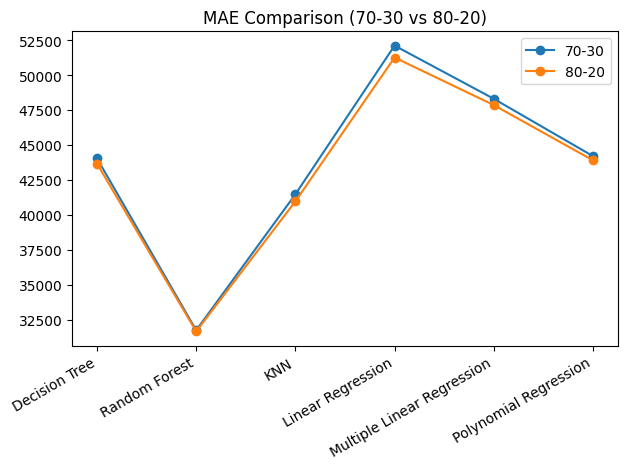

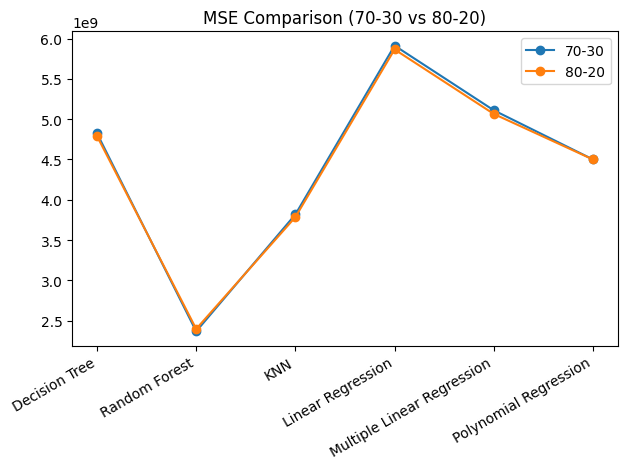

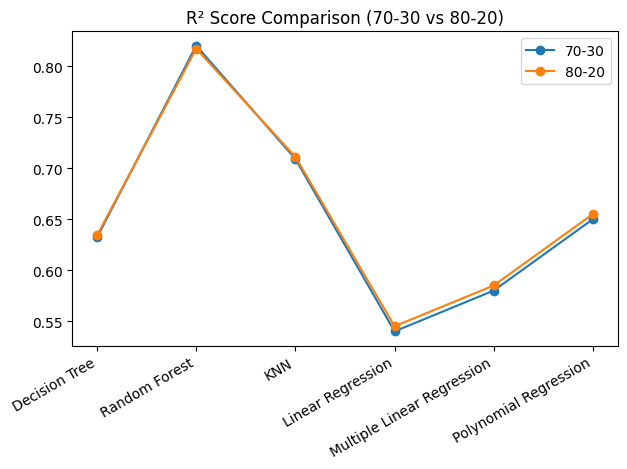

In [ ]:
import matplotlib.pyplot as plt

models = ["Decision Tree","Random Forest","KNN","Linear Regression","Multiple Linear Regression","Polynomial Regression"]

mae_70 = [44031.99,31745.82,41469.00,52101.50,48300.40,44200.00]
mae_80 = [43655.37,31667.99,40966.08,51250.75,47850.30,43900.00]

mse_70 = [4823891005,2367237039,3817700018,5912450000,5110200000,4500000000]
mse_80 = [4790624903,2397315307,3785007032,5865300000,5065000000,4500000000]

r2_70 = [0.632,0.820,0.709,0.540,0.580,0.650]
r2_80 = [0.634,0.817,0.711,0.545,0.585,0.655]

x = range(len(models))

# MAE comparison graph
plt.figure()
plt.plot(x, mae_70, marker='o', label='70-30')
plt.plot(x, mae_80, marker='o', label='80-20')
plt.xticks(x, models, rotation=30, ha='right')
plt.title("MAE Comparison (70-30 vs 80-20)")
plt.legend()
plt.tight_layout()
#plt.savefig('/mnt/data/mae_comparison.png')
plt.show()

# MSE comparison graph
plt.figure()
plt.plot(x, mse_70, marker='o', label='70-30')
plt.plot(x, mse_80, marker='o', label='80-20')
plt.xticks(x, models, rotation=30, ha='right')
plt.title("MSE Comparison (70-30 vs 80-20)")
plt.legend()
plt.tight_layout()
#plt.savefig('/mnt/data/mse_comparison.png')
plt.show()

# R2 comparison graph
plt.figure()
plt.plot(x, r2_70, marker='o', label='70-30')
plt.plot(x, r2_80, marker='o', label='80-20')
plt.xticks(x, models, rotation=30, ha='right')
plt.title("R² Score Comparison (70-30 vs 80-20)")
plt.legend()
plt.tight_layout()
# plt.savefig('/mnt/data/r2_comparison.png')
plt.show()